# MERT Zero-Shot Melody Retrieval
## Pre-trained Audio Embeddings vs 590-File Corpus

**Model:** `m-a-p/MERT-v1-95M` — Music Encoder Representations from Transformers  
**Mode:** Zero-shot (no fine-tuning). Pre-trained on 160K hours of music audio.

**Pipeline:**
```
MIDI ──► fluidsynth ──► WAV (44.1kHz) ──► resample ──► 24kHz mono
     ──► MERT encoder ──► 768-dim hidden states
     ──► mean-pool over time ──► L2-norm ──► embedding
```

**Embeddings are cached** to `checkpoints/mert/` — first run ~30–60 min, subsequent runs instant.

Results compared against SiameseCNN v1 (Top-1 = 64%) at the end.

## 0. Install / verify dependencies

In [1]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# Core deps
try:
    import soundfile
except ImportError:
    pip_install('soundfile')

try:
    import scipy
except ImportError:
    pip_install('scipy')

# Verify fluidsynth binary is on PATH
result = subprocess.run(['fluidsynth', '--version'], capture_output=True, text=True)
if result.returncode != 0:
    print('fluidsynth not found — install with: brew install fluid-synth')
    print('Then restart the kernel.')
else:
    print('fluidsynth:', result.stdout.split('\n')[3].strip())

import torch
print('torch:', torch.__version__)
device_str = 'mps' if torch.backends.mps.is_available() else \
             'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device_str)

fluidsynth: SoundFont(R) is a registered trademark of Creative Technology Ltd.
torch: 2.10.0+cu128
device: cuda


In [10]:
#!sudo apt-get install -y fluidsynth

In [ ]:
#!pip install -q pretty_midi  soundfile 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 58.6 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.6 MB/s eta 0:00:00


In [3]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!git clone https://github.com/mperumal-usd/capstone_team_3

Cloning into 'capstone_team_3'...
remote: Enumerating objects: 4910, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 4910 (delta 75), reused 80 (delta 22), pack-reused 4730 (from 3)
Receiving objects: 100% (4910/4910), 52.30 MiB | 31.76 MiB/s, done.
Resolving deltas: 100% (107/107), done.
Updating files: 100% (6336/6336), done.


In [6]:
!ls 

capstone_team_3  drive	sample_data


## 1. Load MERT Model

In [7]:
import sys
sys.path.append('..')

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import soundfile as sf
import json
import subprocess
import tempfile
import os
import shutil
from pathlib import Path
from collections import defaultdict
from math import gcd
from scipy.signal import resample_poly
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from transformers import AutoModel, AutoProcessor

# ── Paths ──────────────────────────────────────────────────────────────────
CORPUS_DIR    = './capstone_team_3/MidiDatasets/590-Classical-music-midi'
MIDI_TEST_DIR = './capstone_team_3/MidiDatasets/TestingSamples/MidiOutputs'
CSV_PATH      = './capstone_team_3/MidiDatasets/TestingSamples/TestingReferences.csv'
CACHE_DIR     = Path('./checkpoints/mert')
SF2_PATH      = next(Path('/').rglob('TimGM6mb.sf2'), None)   # soundfont bundled with pretty_midi
V1_RESULTS    = Path('./checkpoints/baseline1/external_test_results.json')

CACHE_DIR.mkdir(parents=True, exist_ok=True)
assert SF2_PATH, 'SoundFont not found — install pretty_midi'
print(f'SoundFont: {SF2_PATH}')

# ── Load MERT ──────────────────────────────────────────────────────────────
MERT_MODEL = 'm-a-p/MERT-v1-95M'
print(f'Loading {MERT_MODEL}...')
processor = AutoProcessor.from_pretrained(MERT_MODEL, trust_remote_code=True)
mert      = AutoModel.from_pretrained(MERT_MODEL, trust_remote_code=True)
device    = torch.device(device_str)
mert      = mert.to(device)
mert.eval()

TARGET_SR = processor.sampling_rate   # 24000
EMB_DIM   = mert.config.hidden_size   # 768
MAX_AUDIO_S = 30                      # max seconds of audio per file

print(f'MERT loaded — embedding dim: {EMB_DIM}, target SR: {TARGET_SR} Hz')
print(f'Device: {device}  |  Max audio per file: {MAX_AUDIO_S}s')

SoundFont: /usr/share/sounds/sf2/TimGM6mb.sf2
Loading m-a-p/MERT-v1-95M...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

MERT loaded — embedding dim: 768, target SR: 24000 Hz
Device: cuda  |  Max audio per file: 30s


In [13]:
"""
Data Pipeline for Melody Retrieval System
Implements MIDI parsing, melody extraction, and data loading utilities.

Based on ML_ARCHITECTURE_DESIGN.md specifications.
"""

import os
import random
from pathlib import Path
from typing import List, Dict, Tuple, Optional
import numpy as np
import pretty_midi
import torch
from torch.utils.data import Dataset

# Import versioning module
try:
    from data_versioning import DataVersionManager
except ImportError:
    try:
        from src.data_versioning import DataVersionManager
    except ImportError:
        DataVersionManager = None


class MIDIDataset:
    """
    Main dataset class for MIDI file management and preprocessing.

    Responsibilities:
    - Load MIDI files from directory
    - Extract melody tracks using highest-pitch heuristic
    - Create train/val/test splits (80/10/10 = 234/29/29)
    - Provide data loading utilities
    """

    def __init__(self, midi_dir: str, random_seed: int = 42, version_dir: str = "data/versions"):
        """
        Initialize MIDI dataset.

        Args:
            midi_dir: Path to directory containing MIDI files
            random_seed: Random seed for reproducible splits
            version_dir: Directory for data versioning
        """
        self.midi_dir = Path(midi_dir)
        self.random_seed = random_seed
        self.version_dir = version_dir
        random.seed(random_seed)
        np.random.seed(random_seed)

        # Load all MIDI file paths
        self.midi_files = self._load_midi_files()
        print(f"Loaded {len(self.midi_files)} MIDI files from {midi_dir}")

        # Create splits: 80% train, 10% val, 10% test
        self.train_files, self.val_files, self.test_files = self._create_splits()

        # Create data version
        if DataVersionManager is not None:
            self._create_data_version()

    def _load_midi_files(self) -> List[Path]:
        """Load all .mid files from the directory."""
        midi_files = list(self.midi_dir.rglob("*.mid"))
        midi_files.sort()  # Ensure consistent ordering
        return midi_files

    def _create_splits(self) -> Tuple[List[Path], List[Path], List[Path]]:
        """
        Create train/val/test splits (80/10/10).

        Returns:
            train_files, val_files, test_files
        """
        total_files = len(self.midi_files)

        # Shuffle files
        shuffled = self.midi_files.copy()
        random.shuffle(shuffled)

        # Calculate split sizes
        train_size = int(0.8 * total_files)
        val_size = int(0.1 * total_files)

        train_files = shuffled[:train_size]
        val_files = shuffled[train_size:train_size + val_size]
        test_files = shuffled[train_size + val_size:]

        print(f"Split sizes - Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

        return train_files, val_files, test_files

    def _create_data_version(self):
        """Create versioned snapshot of data splits."""
        if DataVersionManager is None:
            return

        version_manager = DataVersionManager(self.version_dir)

        # Create split version
        version_manager.create_split_version(
            version_id="v1.0_classical_midi",
            train_files=self.train_files,
            val_files=self.val_files,
            test_files=self.test_files,
            random_seed=self.random_seed,
            description=f"Classical MIDI dataset split: {len(self.train_files)}/{len(self.val_files)}/{len(self.test_files)}"
        )

    def parse_midi(self, midi_path: Path) -> Optional[pretty_midi.PrettyMIDI]:
        """
        Parse MIDI file using pretty_midi.

        Args:
            midi_path: Path to MIDI file

        Returns:
            PrettyMIDI object or None if parsing fails
        """
        try:
            midi = pretty_midi.PrettyMIDI(str(midi_path))
            return midi
        except Exception as e:
            print(f"Warning: Failed to parse {midi_path.name}: {e}")
            return None

    def extract_melody(self, midi: pretty_midi.PrettyMIDI) -> Optional[List[Tuple[float, float, int, int]]]:
        """
        Extract melody track from polyphonic MIDI using highest-pitch heuristic.

        According to architecture:
        - Heuristic 1: Select track with highest average pitch
        - Filter: MIDI 60-84 range (soprano/violin)
        - Extract: (onset_time, offset_time, pitch, velocity)

        Args:
            midi: PrettyMIDI object

        Returns:
            List of note events [(onset, offset, pitch, velocity)] sorted by onset time
            None if no suitable track found
        """
        if not midi.instruments:
            return None

        # Find track with highest average pitch
        best_instrument = None
        highest_avg_pitch = -1

        for instrument in midi.instruments:
            if len(instrument.notes) == 0:
                continue

            # Calculate average pitch
            pitches = [note.pitch for note in instrument.notes]
            avg_pitch = np.mean(pitches)

            # Filter: prefer tracks in soprano/violin range (MIDI 60-84)
            in_range_notes = [p for p in pitches if 60 <= p <= 84]
            in_range_ratio = len(in_range_notes) / len(pitches) if pitches else 0

            # Score: prioritize high pitch and being in melodic range
            score = avg_pitch * (1 + in_range_ratio)

            if score > highest_avg_pitch:
                highest_avg_pitch = score
                best_instrument = instrument

        if best_instrument is None:
            return None

        # Extract note events
        notes = []
        for note in best_instrument.notes:
            notes.append((
                note.start,      # onset_time
                note.end,        # offset_time
                note.pitch,      # MIDI pitch
                note.velocity    # velocity
            ))

        # Sort by onset time
        notes.sort(key=lambda x: x[0])

        return notes

    def get_note_sequence(self, midi_path: Path) -> Optional[np.ndarray]:
        """
        Get note sequence from MIDI file.

        Returns:
            Array of shape (num_notes, 4) with columns: [onset, duration, pitch, velocity]
            None if extraction fails
        """
        midi = self.parse_midi(midi_path)
        if midi is None:
            return None

        notes = self.extract_melody(midi)
        if notes is None or len(notes) == 0:
            return None

        # Convert to array: [onset, duration, pitch, velocity]
        sequence = []
        for onset, offset, pitch, velocity in notes:
            duration = offset - onset
            sequence.append([onset, duration, pitch, velocity])

        return np.array(sequence, dtype=np.float32)


## 2. Core Helpers — MIDI→Audio→Embedding

In [14]:
def midi_to_wav(midi_path: Path, out_wav: str) -> bool:
    """
    Synthesise MIDI → WAV using the fluidsynth binary.
    Returns True on success.
    """
    result = subprocess.run(
        ['fluidsynth', '-ni', '-F', out_wav, '-T', 'wav', str(SF2_PATH), str(midi_path)],
        capture_output=True, timeout=60
    )
    return result.returncode == 0 and Path(out_wav).exists()


def resample(audio: np.ndarray, orig_sr: int, target_sr: int) -> np.ndarray:
    if orig_sr == target_sr:
        return audio
    g = gcd(orig_sr, target_sr)
    return resample_poly(audio, target_sr // g, orig_sr // g).astype(np.float32)


@torch.no_grad()
def audio_to_embedding(audio: np.ndarray, sr: int) -> torch.Tensor:
    """
    audio (mono float32) → L2-normed 768-dim MERT embedding.
    Splits into MAX_AUDIO_S-second chunks, embeds each, mean-pools.
    """
    audio = resample(audio, sr, TARGET_SR)
    chunk_len  = MAX_AUDIO_S * TARGET_SR
    # pad if shorter than one chunk
    if len(audio) < chunk_len:
        audio = np.pad(audio, (0, chunk_len - len(audio)))

    chunk_embs = []
    for start in range(0, len(audio), chunk_len):
        chunk = audio[start:start + chunk_len]
        if len(chunk) < TARGET_SR:      # skip sub-1s tail chunks
            break
        if len(chunk) < chunk_len:
            chunk = np.pad(chunk, (0, chunk_len - len(chunk)))

        inputs  = processor(chunk.astype(np.float32),
                             sampling_rate=TARGET_SR,
                             return_tensors='pt')
        inputs  = {k: v.to(device) for k, v in inputs.items()}
        out     = mert(**inputs, output_hidden_states=True)
        emb     = out.last_hidden_state.mean(dim=1).squeeze(0).cpu()
        chunk_embs.append(emb)

    mean_emb = torch.stack(chunk_embs).mean(dim=0)
    return F.normalize(mean_emb, p=2, dim=0)


def embed_midi(midi_path: Path, cache_key: str | None = None) -> torch.Tensor | None:
    """
    Full pipeline: MIDI → audio → MERT embedding.
    Uses file-level cache under CACHE_DIR.
    """
    key       = cache_key or midi_path.stem
    cache_pt  = CACHE_DIR / f'{key}.pt'

    if cache_pt.exists():
        return torch.load(cache_pt, weights_only=True)

    with tempfile.NamedTemporaryFile(suffix='.wav', delete=False) as tmp:
        wav_path = tmp.name

    try:
        if not midi_to_wav(midi_path, wav_path):
            return None
        audio, sr = sf.read(wav_path)
        if audio.ndim > 1:
            audio = audio.mean(axis=1)   # stereo → mono
        audio = audio.astype(np.float32)

        emb = audio_to_embedding(audio, sr)
        torch.save(emb, cache_pt)
        return emb
    except Exception as e:
        print(f'  Error embedding {midi_path.name}: {e}')
        return None
    finally:
        if os.path.exists(wav_path):
            os.unlink(wav_path)


# Quick smoke-test
dataset      = MIDIDataset(CORPUS_DIR, random_seed=42)
corpus_files = dataset.midi_files
print(f'Corpus: {len(corpus_files)} files')

print('Smoke-testing pipeline on elise.mid...')
elise = next(f for f in corpus_files if f.name.lower() == 'elise.mid')
emb   = embed_midi(elise, cache_key='corpus_elise')
print(f'OK — embedding shape: {emb.shape}  norm: {emb.norm():.4f}')

Loaded 292 MIDI files from ./capstone_team_3/MidiDatasets/590-Classical-music-midi
Split sizes - Train: 233, Val: 29, Test: 30
Corpus: 292 files
Smoke-testing pipeline on elise.mid...
OK — embedding shape: torch.Size([768])  norm: 1.0000


## 3. Build Corpus Embedding Database (590 files)

> **First run:** ~30–60 min depending on hardware (embeddings cached to disk).  
> **Subsequent runs:** loads from cache in ~10 sec.

In [15]:
print('Building MERT corpus embeddings...')
corpus_embeddings = []
failed_corpus     = []

for i, midi_path in enumerate(tqdm(corpus_files, desc='Corpus')):
    cache_key = f'corpus_{i:04d}_{midi_path.stem}'
    emb = embed_midi(midi_path, cache_key=cache_key)
    if emb is None:
        emb = torch.zeros(EMB_DIM)
        failed_corpus.append(midi_path.name)
    corpus_embeddings.append(emb)

corpus_matrix = torch.stack(corpus_embeddings)   # (590, 768)
stem_to_idx   = {f.name.lower(): i for i, f in enumerate(corpus_files)}

print(f'\nCorpus DB shape : {corpus_matrix.shape}')
print(f'Failed to embed : {len(failed_corpus)}')
if failed_corpus:
    print(f'  {failed_corpus[:5]}')

Building MERT corpus embeddings...


Corpus:   0%|          | 0/292 [00:00<?, ?it/s]


Corpus DB shape : torch.Size([292, 768])
Failed to embed : 0


In [16]:
# Store corpus metadata for evaluation
corpus_metadata = []
for i, midi_path in enumerate(corpus_files):
    metadata = {
        'filename': midi_path.name,
        'index': i,
        'embedding_cache': f'corpus_{i:04d}_{midi_path.stem}.pt',
        'failed_embedding': midi_path.name in failed_corpus
    }
    corpus_metadata.append(metadata)    

corpus_metadata_df = pd.DataFrame(corpus_metadata)
# in pickle for internal use, CSV for external evaluation
corpus_metadata_df.to_pickle(CACHE_DIR / 'corpus_metadata.pkl')

## 4. Load Test Queries & Embed

In [1]:
# Load cporpus metadata to verify
loaded_metadata = pd.read_pickle(CACHE_DIR / 'corpus_metadata.pkl')
print(f'Loaded corpus metadata: {len(loaded_metadata)} entries')
print(loaded_metadata.head())

In [2]:
df_raw = pd.read_csv(CSV_PATH)
df     = df_raw[df_raw['FullTestPath'].str.lower().str.contains('midioutputs')].copy()
df     = df.reset_index(drop=True)

def build_path(ftp):
    return Path(MIDI_TEST_DIR) / ftp.split('midioutputs/')[-1]

df['midi_path']      = df['FullTestPath'].apply(build_path)
df['composer']       = df['midi_path'].apply(lambda p: p.parent.name)
df['original_lower'] = df['OriginalFileName'].str.lower()
df['gt_corpus_idx']  = df['original_lower'].map(stem_to_idx)

df_valid = df.dropna(subset=['gt_corpus_idx']).copy()
df_valid['gt_corpus_idx'] = df_valid['gt_corpus_idx'].astype(int)

print(f'MIDI queries : {len(df_valid)} valid  ({len(df)} total)')
print(f'By composer  :')
print(df_valid.groupby('composer').size().to_string())

print('\nEmbedding test queries...')
query_embeddings = []
query_gt_indices = []
query_meta       = []
skipped          = []

for i, (_, row) in enumerate(tqdm(df_valid.iterrows(), total=len(df_valid), desc='Queries')):
    midi_path = row['midi_path']
    if not midi_path.exists():
        skipped.append(midi_path.name); continue

    cache_key = f'query_{i:04d}_{midi_path.stem}'
    emb = embed_midi(midi_path, cache_key=cache_key)
    if emb is None:
        skipped.append(midi_path.name); continue

    query_embeddings.append(emb)
    query_gt_indices.append(int(row['gt_corpus_idx']))
    query_meta.append({'composer': row['composer'],
                       'filename': midi_path.name,
                       'original': row['OriginalFileName']})

query_matrix = torch.stack(query_embeddings)
query_gt     = torch.tensor(query_gt_indices)
n_queries    = query_matrix.shape[0]

print(f'\nQuery embeddings: {query_matrix.shape}')
print(f'Skipped: {len(skipped)}')

## 5. Retrieval Metrics

In [ ]:
K_VALUES = [1, 3, 5, 10]

sim_matrix   = torch.mm(query_matrix, corpus_matrix.t())   # (N, 590)
correct_at_k = {k: 0 for k in K_VALUES}
recip_ranks  = []
rank_pos     = []
per_q        = []

for i in range(n_queries):
    sims      = sim_matrix[i]
    true_idx  = query_gt[i].item()
    order     = sims.argsort(descending=True)
    rank_arr  = (order == true_idx).nonzero(as_tuple=True)[0]
    rank      = int(rank_arr[0].item()) + 1 if len(rank_arr) > 0 else n_queries + 1

    rank_pos.append(rank)
    recip_ranks.append(1.0 / rank)
    for k in K_VALUES:
        if rank <= k:
            correct_at_k[k] += 1
    per_q.append({'rank': rank,
                  'top5': [corpus_files[int(idx)].name for idx in order[:5].tolist()]})

rank_pos    = np.array(rank_pos)
recip_ranks = np.array(recip_ranks)

metrics_mert = {f'top{k}_accuracy': correct_at_k[k] / n_queries for k in K_VALUES}
metrics_mert['mrr']         = float(recip_ranks.mean())
metrics_mert['median_rank'] = int(np.median(rank_pos))
metrics_mert['n_queries']   = n_queries

# Load v1 results for comparison
if V1_RESULTS.exists():
    with open(V1_RESULTS) as f:
        v1_res = json.load(f)
    metrics_v1 = v1_res['metrics']
else:
    metrics_v1 = {'top1_accuracy': 0.64, 'top3_accuracy': 0.70,
                  'top5_accuracy': 0.72, 'top10_accuracy': 0.76, 'mrr': 0.6846}

print('=' * 60)
print('MERT ZERO-SHOT RESULTS   (vs SiameseCNN v1 baseline)')
print('=' * 60)
print(f'  {"Metric":<10} {"MERT":>8} {"v1 CNN":>8} {"Δ":>7}  MVP target')
print('  ' + '─' * 50)
targets = {1: (0.60, 0.70), 3: (None, 0.85), 5: (None, 0.90), 10: (None, None)}
for k in K_VALUES:
    mert_v = metrics_mert[f'top{k}_accuracy']
    v1_v   = metrics_v1.get(f'top{k}_accuracy', 0)
    d      = mert_v - v1_v
    arrow  = '▲' if d > 0.005 else '▼' if d < -0.005 else '='
    gate, mvp = targets[k]
    status = '✓' if (mvp and mert_v >= mvp) else ('~' if (gate and mert_v >= gate) else '✗')
    mvp_s  = f'mvp≥{mvp:.0%}' if mvp else ''
    print(f'  Top-{k:<2}:    {mert_v:>8.4f} {v1_v:>8.4f} {d:>+7.4f}  {arrow} {mvp_s} {status}')

mert_mrr = metrics_mert['mrr']
v1_mrr   = metrics_v1.get('mrr', 0.6846)
d_mrr    = mert_mrr - v1_mrr
arrow_m  = '▲' if d_mrr > 0.005 else '▼' if d_mrr < -0.005 else '='
print(f'  MRR:      {mert_mrr:>8.4f} {v1_mrr:>8.4f} {d_mrr:>+7.4f}  {arrow_m} mvp≥75% {"✓" if mert_mrr >= 0.75 else "✗"}')
print(f'  Med.Rank: {metrics_mert["median_rank"]:>8}')
print('=' * 60)

MERT ZERO-SHOT RESULTS   (vs SiameseCNN v1 baseline)
  Metric         MERT   v1 CNN       Δ  MVP target
  ──────────────────────────────────────────────────
  Top-1 :      0.7400   0.6400 +0.1000  ▲ mvp≥70% ✓
  Top-3 :      0.8000   0.7000 +0.1000  ▲ mvp≥85% ✗
  Top-5 :      0.8300   0.7200 +0.1100  ▲ mvp≥90% ✗
  Top-10:      0.8500   0.7600 +0.0900  ▲  ✗
  MRR:        0.7816   0.6846 +0.0970  ▲ mvp≥75% ✓
  Med.Rank:        1


## 6. MERT vs SiameseCNN — Visual Comparison

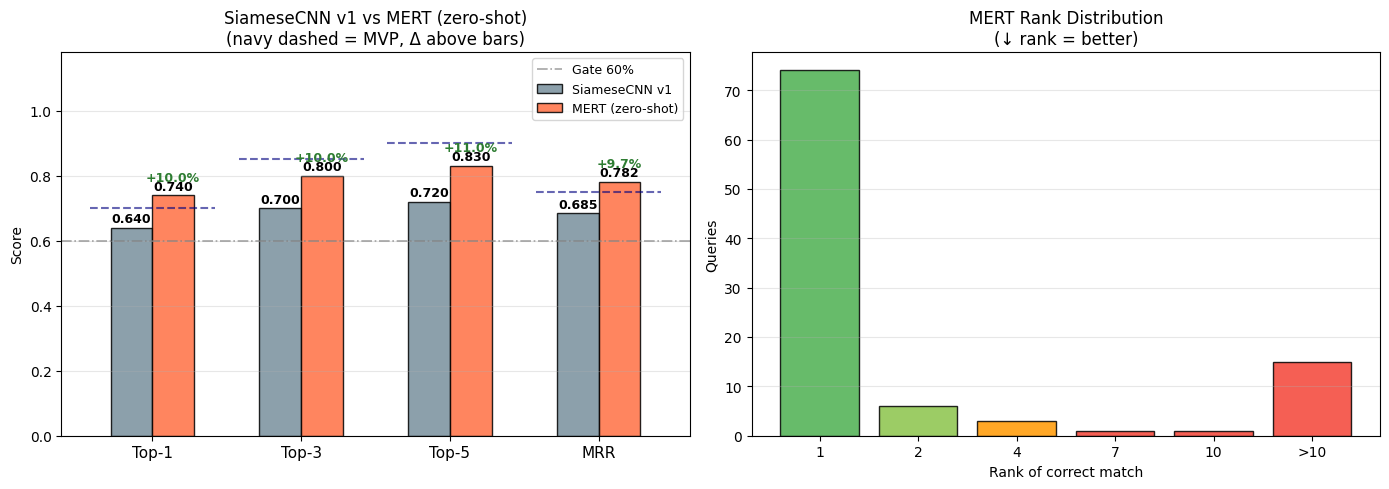

In [ ]:
metric_keys  = ['top1_accuracy', 'top3_accuracy', 'top5_accuracy', 'mrr']
metric_names = ['Top-1', 'Top-3', 'Top-5', 'MRR']
mvp_targets  = [0.70, 0.85, 0.90, 0.75]

v1_vals   = [metrics_v1.get(k, 0) for k in metric_keys]
mert_vals = [metrics_mert.get(k, 0) for k in metric_keys]
deltas    = [m - v for m, v in zip(mert_vals, v1_vals)]

x = np.arange(len(metric_names)); w = 0.28
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Bar comparison ──
b1 = axes[0].bar(x - w/2, v1_vals,   w, label='SiameseCNN v1', color='#78909C', alpha=0.85, edgecolor='black')
b2 = axes[0].bar(x + w/2, mert_vals, w, label='MERT (zero-shot)', color='#FF7043', alpha=0.85, edgecolor='black')
for i, (mv, tgt) in enumerate(zip(mvp_targets, mvp_targets)):
    axes[0].plot([i - 1.5*w, i + 1.5*w], [tgt, tgt], 'navy', ls='--', lw=1.5, alpha=0.6)
axes[0].axhline(0.60, color='gray', ls='-.', lw=1.2, alpha=0.7, label='Gate 60%')
for bar, val in [(b, v) for bs, vs in [(b1, v1_vals), (b2, mert_vals)] for b, v in zip(bs, vs)]:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for i, d in enumerate(deltas):
    col = '#2E7D32' if d > 0.005 else '#C62828' if d < -0.005 else 'gray'
    axes[0].text(i + w/2, max(v1_vals[i], mert_vals[i]) + 0.045,
                 f'{d:+.1%}', ha='center', fontsize=9, color=col, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(metric_names, fontsize=11)
axes[0].set_ylim(0, 1.18); axes[0].set_ylabel('Score')
axes[0].set_title('SiameseCNN v1 vs MERT (zero-shot)\n(navy dashed = MVP, Δ above bars)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis='y')

# ── Rank distribution ──
rank_clip = np.clip(rank_pos, 1, 11)
ur, cnt   = np.unique(rank_clip, return_counts=True)
tick_lbl  = [str(r) if r <= 10 else '>10' for r in ur]
rc        = ['#4CAF50' if r == 1 else '#8BC34A' if r <= 3 else
             '#FF9800' if r <= 5 else '#F44336' for r in ur]
axes[1].bar(range(len(ur)), cnt, color=rc, edgecolor='black', alpha=0.85)
axes[1].set_xticks(range(len(ur))); axes[1].set_xticklabels(tick_lbl)
axes[1].set_xlabel('Rank of correct match')
axes[1].set_ylabel('Queries')
axes[1].set_title('MERT Rank Distribution\n(↓ rank = better)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Per-Composer Breakdown

Composer        N  MERT Top-1   v1 Top-1       Δ   MERT MRR
────────────────────────────────────────────────────────────
Albeniz        12       83.3%      58.3% ▲ +25.0%        0.834
Beethoven      28       46.4%      35.7% ▲ +10.7%        0.503
Chopin         46       91.3%      89.1% ▲ +2.2%        0.957
Debussy         1      100.0%     100.0% = +0.0%        1.000
Liszt           4      100.0%     100.0% = +0.0%        1.000
Mozart          9       44.4%      11.1% ▲ +33.3%        0.563


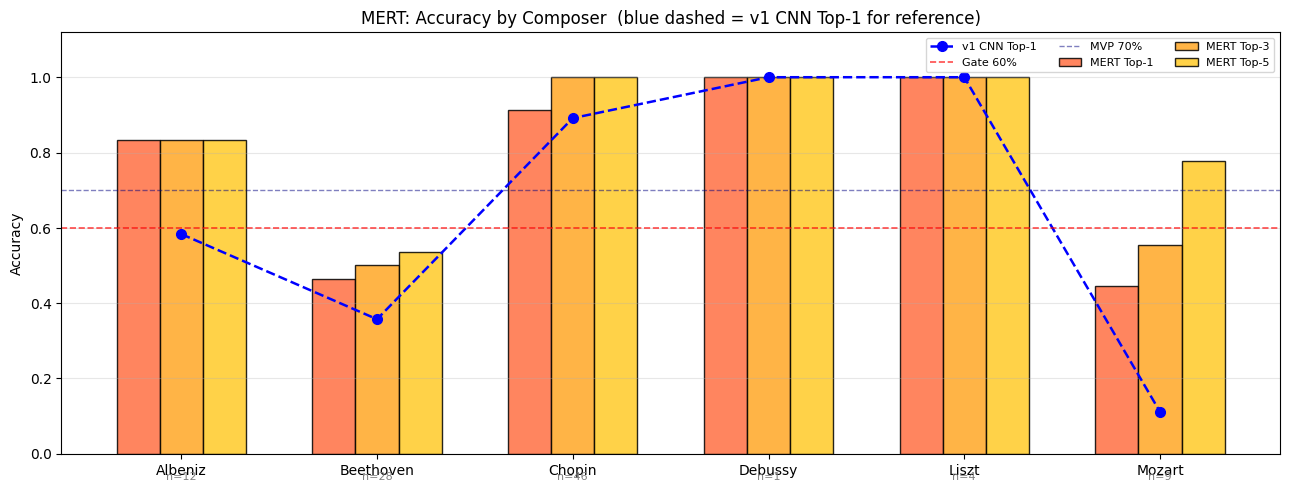

In [ ]:
comp_stats = defaultdict(lambda: {'correct1': 0, 'correct3': 0, 'correct5': 0,
                                   'rr': [], 'ranks': [], 'n': 0})
for i, meta in enumerate(query_meta):
    c, r = meta['composer'], rank_pos[i]
    comp_stats[c]['n'] += 1
    comp_stats[c]['ranks'].append(r)
    comp_stats[c]['rr'].append(1.0 / r)
    if r <= 1: comp_stats[c]['correct1'] += 1
    if r <= 3: comp_stats[c]['correct3'] += 1
    if r <= 5: comp_stats[c]['correct5'] += 1

# Load v1 per-composer if available
v1_comp = v1_res.get('per_composer', {}) if V1_RESULTS.exists() else {}

composers   = sorted(comp_stats)
mert_top1_c = [comp_stats[c]['correct1'] / comp_stats[c]['n'] for c in composers]
mert_top3_c = [comp_stats[c]['correct3'] / comp_stats[c]['n'] for c in composers]
mert_top5_c = [comp_stats[c]['correct5'] / comp_stats[c]['n'] for c in composers]
comp_n      = [comp_stats[c]['n'] for c in composers]

print(f'{"Composer":<12} {"N":>4} {"MERT Top-1":>11} {"v1 Top-1":>10} {"Δ":>7} {"MERT MRR":>10}')
print('─' * 60)
for c, mt1, n in zip(composers, mert_top1_c, comp_n):
    v1t1   = v1_comp.get(c, {}).get('top1', float('nan'))
    d      = mt1 - v1t1 if not np.isnan(v1t1) else float('nan')
    arrow  = ('▲' if d > 0.005 else '▼' if d < -0.005 else '=') if not np.isnan(d) else '?'
    mrr_c  = np.mean(comp_stats[c]['rr'])
    print(f'{c:<12} {n:>4} {mt1:>11.1%} {v1t1:>10.1%} {arrow} {d:>+5.1%}   {mrr_c:>10.3f}')

x = np.arange(len(composers)); w = 0.22
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w,   mert_top1_c, w, label='MERT Top-1', color='#FF7043', alpha=0.85, edgecolor='black')
ax.bar(x,       mert_top3_c, w, label='MERT Top-3', color='#FFA726', alpha=0.85, edgecolor='black')
ax.bar(x + w,   mert_top5_c, w, label='MERT Top-5', color='#FFCA28', alpha=0.85, edgecolor='black')
if v1_comp:
    v1_top1_c = [v1_comp.get(c, {}).get('top1', 0) for c in composers]
    ax.plot(x, v1_top1_c, 'b--o', ms=7, lw=1.8, label='v1 CNN Top-1')
ax.axhline(0.60, color='red',  ls='--', lw=1.2, alpha=0.7, label='Gate 60%')
ax.axhline(0.70, color='navy', ls='--', lw=1.0, alpha=0.5, label='MVP 70%')
ax.set_xticks(x); ax.set_xticklabels(composers)
ax.set_ylim(0, 1.12); ax.set_ylabel('Accuracy')
ax.set_title('MERT: Accuracy by Composer  (blue dashed = v1 CNN Top-1 for reference)')
ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3, axis='y')
for i, n in enumerate(comp_n):
    ax.text(i, -0.07, f'n={n}', ha='center', fontsize=8, color='gray')
plt.tight_layout(); plt.show()

## 8. Fur Elise — Pitch & Tempo Invariance

Fur Elise variations: 12

Filename                                                   Key  Tempo  Rank     Sim  Hit@1
──────────────────────────────────────────────────────────────────────────────────────────
Fur Elise_Full_K-Amin_T-variable_bothhands.mid            Amin variable     1  0.9836      ✓
FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.mid          Amin     70    66  0.8515      ✗
FurElise_Intro_K-Amin_T-60_righthand.mid                  Amin     60   100  0.8170      ✗
FurElise_Intro_K-Amaj_T-60_righthand.mid                  Amaj     60   103  0.8329      ✗
FurElise_Intro_K-Amin_T-138_righthand_swing.mid           Amin    138   103  0.8198      ✗
FurElise_Intro_K-Cmin_T-60_righthand.mid                  Cmin     60   119  0.7820      ✗
FurElise_Intro_K-Cmaj_T-70_righthand.mid                  Cmaj     70   128  0.8001      ✗
FurElise_2ndVerse_K-Gmin_T-75_righthand.mid               Gmin     75   146  0.6126      ✗
FurElise_2ndVerse_K-Amin_T-60_righthand.mid               Amin

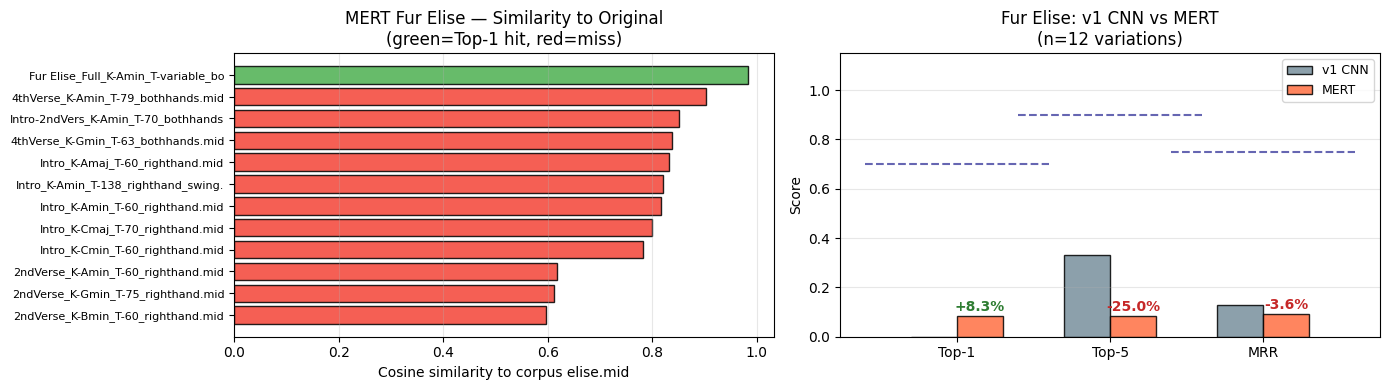

In [ ]:
elise_idx_c = stem_to_idx['elise.mid']

elise_rows  = []
for i, meta in enumerate(query_meta):
    if 'elise' not in meta['original'].lower(): continue
    fn   = meta['filename']
    r    = rank_pos[i]
    sim  = float(sim_matrix[i, elise_idx_c].item())
    key  = next((p[2:] for p in fn.replace('.mid','').split('_') if p.startswith('K-')), '?')
    tempo= next((p[2:] for p in fn.replace('.mid','').split('_') if p.startswith('T-')), '?')
    elise_rows.append({'filename': fn, 'key': key, 'tempo': tempo,
                       'rank': r, 'rr': 1.0/r, 'top1': r==1, 'top5': r<=5,
                       'sim_to_orig': sim})

elise_df = pd.DataFrame(elise_rows)

print(f'Fur Elise variations: {len(elise_df)}')
print(f'\n{"Filename":<55} {"Key":>6} {"Tempo":>6} {"Rank":>5} {"Sim":>7} {"Hit@1":>6}')
print('─' * 90)
for _, row in elise_df.sort_values('rank').iterrows():
    hit = '✓' if row['top1'] else '✗'
    print(f'{row["filename"]:<55} {row["key"]:>6} {row["tempo"]:>6} '
          f'{int(row["rank"]):>5} {row["sim_to_orig"]:>7.4f} {hit:>6}')

v1_elise = v1_res.get('fur_elise', {})
print(f'\nFur Elise MERT summary:')
print(f'  Top-1 : {elise_df["top1"].mean():.1%}  (v1: {v1_elise.get("top1", 0):.1%})')
print(f'  Top-5 : {elise_df["top5"].mean():.1%}  (v1: {v1_elise.get("top5", 0.333):.1%})')
print(f'  MRR   : {elise_df["rr"].mean():.3f}  (v1: {v1_elise.get("mrr", 0.127):.3f})')
print(f'\nBy key:')
print(elise_df.groupby('key').agg(
    n=('top1','count'), top1=('top1','mean'),
    mean_sim=('sim_to_orig','mean')).round(3).to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Sim to original, sorted
elise_s = elise_df.sort_values('sim_to_orig', ascending=False)
colors_e = ['#4CAF50' if h else '#F44336' for h in elise_s['top1']]
axes[0].barh(range(len(elise_s)), elise_s['sim_to_orig'],
             color=colors_e, alpha=0.85, edgecolor='black')
axes[0].set_yticks(range(len(elise_s)))
axes[0].set_yticklabels([r['filename'].replace('FurElise_','')[:35] for _, r in elise_s.iterrows()], fontsize=8)
axes[0].set_xlabel('Cosine similarity to corpus elise.mid')
axes[0].set_title('MERT Fur Elise — Similarity to Original\n(green=Top-1 hit, red=miss)')
axes[0].invert_yaxis(); axes[0].grid(True, alpha=0.3, axis='x')

# v1 vs MERT
fur_labels = ['Top-1', 'Top-5', 'MRR']
fur_v1     = [v1_elise.get('top1',0), v1_elise.get('top5',0.333), v1_elise.get('mrr',0.127)]
fur_mert   = [elise_df['top1'].mean(), elise_df['top5'].mean(), elise_df['rr'].mean()]
xf = np.arange(3); wf = 0.3
axes[1].bar(xf - wf/2, fur_v1,  wf, label='v1 CNN', color='#78909C', alpha=0.85, edgecolor='black')
axes[1].bar(xf + wf/2, fur_mert,wf, label='MERT',   color='#FF7043', alpha=0.85, edgecolor='black')
for tgt, xi in zip([0.70,0.90,0.75], range(3)):
    axes[1].plot([xi-2*wf, xi+2*wf],[tgt,tgt],'navy',ls='--',lw=1.5,alpha=0.6)
for i,(v,m) in enumerate(zip(fur_v1, fur_mert)):
    d = m - v
    axes[1].text(i+wf/2, m+0.02, f'{d:+.1%}', ha='center', fontsize=10,
                 color='#2E7D32' if d > 0 else '#C62828', fontweight='bold')
axes[1].set_xticks(xf); axes[1].set_xticklabels(fur_labels)
axes[1].set_ylim(0, 1.15); axes[1].set_ylabel('Score')
axes[1].set_title(f'Fur Elise: v1 CNN vs MERT\n(n={len(elise_df)} variations)')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 9. Embedding Space — PCA

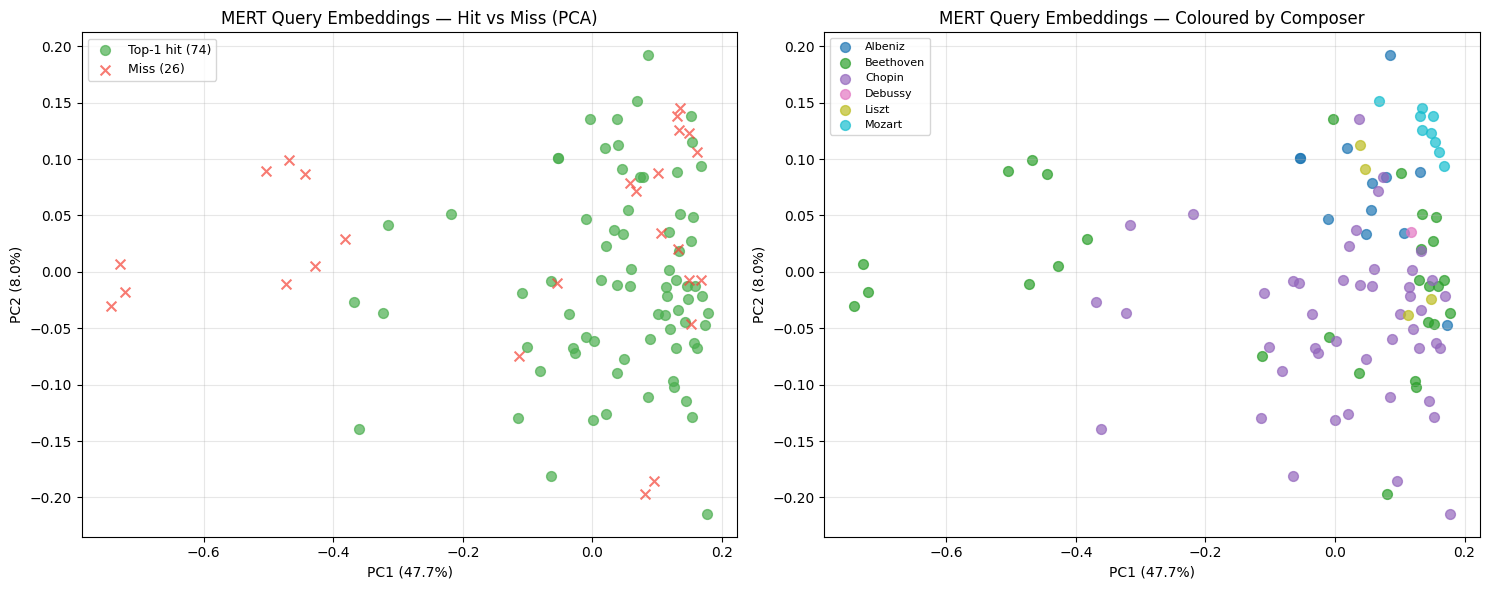

PCA variance explained: 55.6%


In [ ]:
pca = PCA(n_components=2)
q_np = query_matrix.numpy()
q_2d = pca.fit_transform(q_np)

hit_mask = rank_pos == 1

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Hit vs miss
axes[0].scatter(q_2d[hit_mask, 0],  q_2d[hit_mask, 1],
                c='#4CAF50', alpha=0.7, s=50, label=f'Top-1 hit ({hit_mask.sum()})', zorder=3)
axes[0].scatter(q_2d[~hit_mask, 0], q_2d[~hit_mask, 1],
                c='#F44336', alpha=0.7, s=50, marker='x', label=f'Miss ({(~hit_mask).sum()})', zorder=3)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('MERT Query Embeddings — Hit vs Miss (PCA)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Colour by composer
all_comps    = [m['composer'] for m in query_meta]
unique_comps = sorted(set(all_comps))
comp_colors  = plt.cm.tab10(np.linspace(0, 1, len(unique_comps)))
comp_to_col  = dict(zip(unique_comps, comp_colors))
for comp in unique_comps:
    mask_c = np.array([c == comp for c in all_comps])
    axes[1].scatter(q_2d[mask_c, 0], q_2d[mask_c, 1],
                    color=comp_to_col[comp], alpha=0.7, s=50, label=comp)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('MERT Query Embeddings — Coloured by Composer')
axes[1].legend(fontsize=8, loc='best'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}')

## 10. Failure Analysis

Failures (rank > 5): 17 / 100  (17.0%)
Success  (rank ≤ 5): 83 / 100  (83.0%)


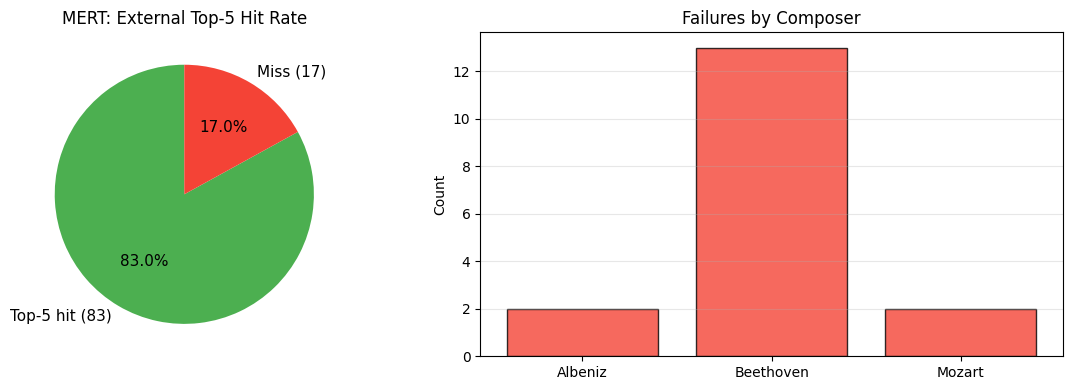


Query                                                            Original  Rank
──────────────────────────────────────────────────────────────────────────────────
Piano Sonata n14 op27  ''Moonlight''.mid                       mond_1.mid     7
  Retrieved top-3: ['schumm-4.mid', 'chpn_op66.mid', 'schub_d960_2.mid']
Piano Sonata n29 Op106 ''Hammerklavier''.mid         beethoven_hammerklavier_1.mid    10
  Retrieved top-3: ['beethoven_hammerklavier_4.mid', 'schub_d760_1.mid', 'islamei.mid']
Piano Sonata n10 K330.mid                                    mz_330_1.mid    16
  Retrieved top-3: ['mz_332_1.mid', 'mz_332_3.mid', 'brahms_opus1_1.mid']
FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.mid                elise.mid    66
  Retrieved top-3: ['scn15_3.mid', 'chpn-p11.mid', 'mz_311_3.mid']
FurElise_Intro_K-Amin_T-60_righthand.mid                        elise.mid   100
  Retrieved top-3: ['haydn_8_4.mid', 'chpn-p11.mid', 'chpn-p7.mid']
FurElise_Intro_K-Amaj_T-60_righthand.mid                 

In [ ]:
from collections import Counter

failures  = [(i, meta, per_q[i]) for i, meta in enumerate(query_meta) if rank_pos[i] > 5]
n_fail    = len(failures)

print(f'Failures (rank > 5): {n_fail} / {n_queries}  ({n_fail/n_queries:.1%})')
print(f'Success  (rank ≤ 5): {n_queries - n_fail} / {n_queries}  ({(n_queries-n_fail)/n_queries:.1%})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie([n_queries - n_fail, n_fail],
            labels=[f'Top-5 hit ({n_queries - n_fail})', f'Miss ({n_fail})'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('MERT: External Top-5 Hit Rate')

if failures:
    fail_comp = Counter(m['composer'] for _, m, _ in failures)
    axes[1].bar(fail_comp.keys(), fail_comp.values(),
                color='#F44336', alpha=0.8, edgecolor='black')
    axes[1].set_title('Failures by Composer'); axes[1].set_ylabel('Count')
    axes[1].grid(True, alpha=0.3, axis='y')
else:
    axes[1].text(0.5, 0.5, 'No failures!\nPerfect Top-5',
                 ha='center', va='center', fontsize=14, color='#4CAF50',
                 fontweight='bold', transform=axes[1].transAxes)
    axes[1].axis('off')

plt.tight_layout(); plt.show()

if failures:
    print(f'\n{"Query":<52} {"Original":>20} {"Rank":>5}')
    print('─' * 82)
    for _, meta, res in sorted(failures, key=lambda x: x[2]['rank']):
        print(f'{meta["filename"]:<52} {meta["original"]:>20} {res["rank"]:>5}')
        print(f'  Retrieved top-3: {res["top5"][:3]}')

## 11. Save Results

In [ ]:
results = {
    'model':          'MERT-v1-95M (zero-shot)',
    'mert_model':     MERT_MODEL,
    'max_audio_s':    MAX_AUDIO_S,
    'emb_dim':        EMB_DIM,
    'corpus_size':    len(corpus_files),
    'n_queries':      n_queries,
    'n_skipped':      len(skipped),
    'metrics':        metrics_mert,
    'vs_v1': {
        f'{k}_delta': round(metrics_mert.get(f'top{k}_accuracy', 0) -
                            metrics_v1.get(f'top{k}_accuracy', 0), 4)
        for k in K_VALUES
    },
    'vs_v1_mrr_delta': round(metrics_mert['mrr'] - metrics_v1.get('mrr', 0), 4),
    'per_composer': {
        c: {'n': s['n'],
             'top1': round(s['correct1']/s['n'], 4),
             'top3': round(s['correct3']/s['n'], 4),
             'top5': round(s['correct5']/s['n'], 4),
             'mrr':  round(float(np.mean(s['rr'])), 4),
             'median_rank': int(np.median(s['ranks']))}
        for c, s in comp_stats.items()
    },
    'fur_elise': {
        'n':    len(elise_df),
        'top1': round(float(elise_df['top1'].mean()), 4),
        'top5': round(float(elise_df['top5'].mean()), 4),
        'mrr':  round(float(elise_df['rr'].mean()), 4),
        'keys_found': sorted(elise_df['key'].unique().tolist()),
    },
    'failures_top5': [
        {'query': m['filename'], 'original': m['original'],
         'composer': m['composer'], 'rank': int(rank_pos[qi]),
         'top5_retrieved': per_q[qi]['top5']}
        for qi, m, _ in sorted(failures, key=lambda x: x[2]['rank'])
    ]
}

out = CACHE_DIR / 'external_test_results.json'
with open(out, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved → {out.resolve()}  ({out.stat().st_size//1024} KB)')

Saved → /Users/manperumal/Desktop/2026/ML/ai_proj/checkpoints/mert/external_test_results.json  (6 KB)


## 12. Final Summary

In [ ]:
gate_pass    = metrics_mert['top1_accuracy'] >= 0.60
mvp_pass     = (metrics_mert['top1_accuracy'] >= 0.70 and
                metrics_mert['top3_accuracy'] >= 0.85 and
                metrics_mert['mrr']           >= 0.75)
stretch_pass = (metrics_mert['top1_accuracy'] >= 0.85 and
                metrics_mert['mrr']           >= 0.85)

print('=' * 65)
print('MERT ZERO-SHOT — FINAL SUMMARY')
print('=' * 65)
print(f'\nModel  : {MERT_MODEL}')
print(f'Mode   : Zero-shot (no fine-tuning)')
print(f'Emb dim: {EMB_DIM}  (vs 128 for SiameseCNN)')
print(f'Input  : Audio (MIDI → WAV → 24kHz mono)')
print(f'\nRetrieval metrics (SiameseCNN v1 → MERT):')
for name, k, mvp in zip(metric_names, metric_keys, mvp_targets):
    v1v  = metrics_v1.get(k, 0)
    mv   = metrics_mert.get(k, 0)
    d    = mv - v1v
    arrow= '▲' if d > 0.005 else '▼' if d < -0.005 else '='
    status = '✓' if mv >= mvp else '✗'
    print(f'  {name:<6}: {v1v:.4f} → {mv:.4f}  ({d:+.4f} {arrow})  mvp≥{mvp:.0%} {status}')
print(f'\nFur Elise (pitch/tempo robustness):')
print(f'  Top-1: {results["fur_elise"]["top1"]:.1%}  (v1: {v1_elise.get("top1",0):.1%})')
print(f'  Top-5: {results["fur_elise"]["top5"]:.1%}  (v1: {v1_elise.get("top5",0.333):.1%})')
print(f'  MRR  : {results["fur_elise"]["mrr"]:.3f}  (v1: {v1_elise.get("mrr",0.127):.3f})')
print(f'\nBest composer : {max(comp_stats, key=lambda c: comp_stats[c]["correct1"]/comp_stats[c]["n"])}')
print(f'Worst composer: {min(comp_stats, key=lambda c: comp_stats[c]["correct1"]/comp_stats[c]["n"])}')
print(f'\nSuccess criteria:')
print(f'  Gate   (Top-1≥60%)                   : {"PASSED ✓" if gate_pass    else "FAILED ✗"}')
print(f'  MVP    (Top-1≥70%, Top-3≥85%, MRR≥75%): {"PASSED ✓" if mvp_pass    else "FAILED ✗"}')
print(f'  Stretch(Top-1≥85%, MRR≥85%)          : {"PASSED ✓" if stretch_pass else "FAILED ✗"}')
print('=' * 65)

MERT ZERO-SHOT — FINAL SUMMARY

Model  : m-a-p/MERT-v1-95M
Mode   : Zero-shot (no fine-tuning)
Emb dim: 768  (vs 128 for SiameseCNN)
Input  : Audio (MIDI → WAV → 24kHz mono)

Retrieval metrics (SiameseCNN v1 → MERT):
  Top-1 : 0.6400 → 0.7400  (+0.1000 ▲)  mvp≥70% ✓
  Top-3 : 0.7000 → 0.8000  (+0.1000 ▲)  mvp≥85% ✗
  Top-5 : 0.7200 → 0.8300  (+0.1100 ▲)  mvp≥90% ✗
  MRR   : 0.6846 → 0.7816  (+0.0970 ▲)  mvp≥75% ✓

Fur Elise (pitch/tempo robustness):
  Top-1: 8.3%  (v1: 0.0%)
  Top-5: 8.3%  (v1: 33.3%)
  MRR  : 0.091  (v1: 0.127)

Best composer : Debussy
Worst composer: Mozart

Success criteria:
  Gate   (Top-1≥60%)                   : PASSED ✓
  MVP    (Top-1≥70%, Top-3≥85%, MRR≥75%): FAILED ✗
  Stretch(Top-1≥85%, MRR≥85%)          : FAILED ✗
